<a href="https://colab.research.google.com/github/shatlykgurdov/3.1.2/blob/main/multicollinearity-shatlyk-gwp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Mask the Diagonal

In [9]:
# ============================================
# GWP 2
# Multicollinearity – Bitcoin (Jan 2024 – Dec 2025)
# Shatlyk Gurdov
import numpy as np
import pandas as pd
import yfinance as yf

start_date = "2024-01-01"
end_date   = "2025-12-31"

raw = yf.download("BTC-USD", start=start_date, end=end_date, progress=False)

# Flatten columns if yfinance returns MultiIndex
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = [c[0] for c in raw.columns]

# Use Adj Close if available; else Close
close_col = "Adj Close" if "Adj Close" in raw.columns else "Close"

df = raw[[close_col, "Volume"]].dropna().copy()
df = df.rename(columns={close_col: "Close", "Volume": "Volume"})

# IMPORTANT: enforce timeframe strictly (prevents 2026 rows)
df = df.loc[(df.index >= start_date) & (df.index <= end_date)].copy()

# Create the same columns as the reference
df["Price"] = df["Close"]                  # keep both, like your teammate's table
df["Returns"] = df["Close"].pct_change()

df["Lag1"] = df["Close"].shift(1)
df["Lag2"] = df["Close"].shift(2)
df["Lag3"] = df["Close"].shift(3)

df["MA5"] = df["Close"].rolling(5).mean()

# RSI(14)
def rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

df["RSI"] = rsi(df["Close"], 14)

df = df.dropna().copy()

print("Date range:", df.index.min(), "to", df.index.max())
df.head()



Date range: 2024-01-15 00:00:00 to 2025-12-30 00:00:00


/tmp/ipython-input-2924784992.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download("BTC-USD", start=start_date, end=end_date, progress=False)


,Close,Volume,Price,Returns,Lag1,Lag2,Lag3,MA5,RSI
Date,,,,,,,,,
2024-01-15,42511.968750,22320220558,42511.968750,0.017124,41796.269531,42842.382812,42853.167969,43274.475000,44.237177
2024-01-16,43154.945312,24062872740,43154.945312,0.015125,42511.968750,41796.269531,42842.382812,42631.746875,43.657924
2024-01-17,42742.652344,20851232595,42742.652344,-0.009554,43154.945312,42511.968750,41796.269531,42609.643750,49.578489
2024-01-18,41262.058594,25218357242,41262.058594,-0.034640,42742.652344,43154.945312,42511.968750,42293.578906,38.481623
2024-01-19,41618.406250,25752407154,41618.406250,0.008636,41262.058594,42742.652344,43154.945312,42258.006250,40.218229


Multicollinearity predictors + seaborn correlation heatmap

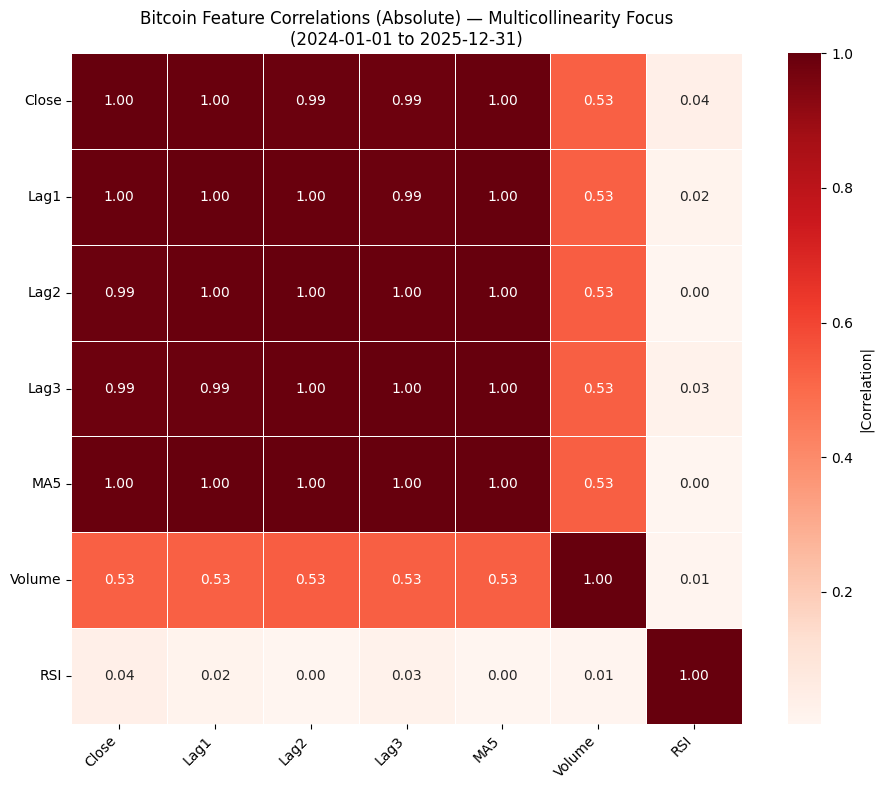

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

predictors = ["Close", "Lag1", "Lag2", "Lag3", "MA5", "Volume", "RSI"]

corr = df[predictors].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr.abs(),                 # absolute correlation = best for multicollinearity
    annot=True,
    fmt=".2f",
    cmap="Reds",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "|Correlation|"}
)
plt.title("Bitcoin Feature Correlations (Absolute) — Multicollinearity Focus\n(2024-01-01 to 2025-12-31)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

VIF table (main multicollinearity proof)

In [11]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[predictors].copy()
X = sm.add_constant(X)

vif_df = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
}).sort_values("VIF", ascending=False)

vif_df

,Variable,VIF
5,MA5,3198.045590
4,Lag3,579.213485
3,Lag2,366.680050
2,Lag1,350.430430
1,Close,281.990787
0,const,28.437267
6,Volume,1.401683
7,RSI,1.348784


Regression coefficients

In [12]:
df["y_next"] = df["Returns"].shift(-1)
reg = df.dropna(subset=predictors + ["y_next"]).copy()

Xr = sm.add_constant(reg[predictors])
yr = reg["y_next"]

model = sm.OLS(yr, Xr).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 y_next   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.352
Date:                Mon, 05 Jan 2026   Prob (F-statistic):              0.223
Time:                        17:01:35   Log-Likelihood:                 1628.7
No. Observations:                 715   AIC:                            -3241.
Df Residuals:                     707   BIC:                            -3205.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0074      0.005      1.484      0.1

Mitigation (simple): removing redundant correlated predictors

In [13]:
reduced_predictors = ["Lag1", "MA5", "Volume", "RSI"]  # example reduced set

X_red = sm.add_constant(reg[reduced_predictors])
model_red = sm.OLS(yr, X_red).fit()
print(model_red.summary())

# VIF after reduction
Xv = sm.add_constant(df[reduced_predictors])
vif_reduced = pd.DataFrame({
    "Variable": Xv.columns,
    "VIF": [variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])]
}).sort_values("VIF", ascending=False)

vif_reduced


                            OLS Regression Results                            
Dep. Variable:                 y_next   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.526
Date:                Mon, 05 Jan 2026   Prob (F-statistic):              0.193
Time:                        17:02:51   Log-Likelihood:                 1627.0
No. Observations:                 715   AIC:                            -3244.
Df Residuals:                     710   BIC:                            -3221.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0093      0.005      1.927      0.0

,Variable,VIF
2,MA5,224.538589
1,Lag1,223.844575
0,const,26.794301
3,Volume,1.393815
4,RSI,1.101963
